# Inspect PFC First-Level Betas

Single-subject mean beta values within vmPFC for the two parametric modulator contrasts of interest.

Complements the unthresholded group T-map analysis: if the group mean T in vmPFC is driven
by a consistent weak effect across subjects, the beta distribution should be shifted from zero;
if it is driven by a few outliers, the distribution will show a heavy tail.

**Contrasts:**
- `second_stimxqval_chosen`
- `second_stimxhval_chosen`

**vmPFC mask:** Bartra et al. 2013, resampled to MNI152NLin2009cAsym.

**GLM:** `glm2_chosen_all_runs_scrubbed_2025-12-11-11-22`

Contrast paths resolved via `contrasts_manifest.tsv` (name-based, not hardcoded indices).

In [1]:
import os
import re
import glob
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn import image

EXPORTS_DIR = "/mnt/data/learning-habits/spm_outputs/glm2_chosen_all_runs_scrubbed_2025-12-11-11-22"
MASK_DIR    = "/mnt/data/learning-habits/masks/MNI152NLin2009cAsym"

CONTRASTS = {
    "second_stimxQval_chosen": "contrast-03_second_stimxqval_chosen",
    "second_stimxHval_chosen": "contrast-04_second_stimxhval_chosen",
}

subjects_file = os.path.join(EXPORTS_DIR, "second-lvl", "subjects_included.txt")
with open(subjects_file) as f:
    included = set(l.strip() for l in f if l.strip())
print(f"Subjects included in 2nd-level: {len(included)}")

vmpfc_mask = nib.load(os.path.join(MASK_DIR, "vmpfc_bartra2013_MNI152NLin2009cAsym.nii"))
print(f"vmPFC mask voxels: {int((vmpfc_mask.get_fdata() > 0).sum())}")

betas = {name: [] for name in CONTRASTS}

for contrast_name, contrast_dir in CONTRASTS.items():
    con_files = sorted(glob.glob(os.path.join(EXPORTS_DIR, contrast_dir, "*.nii")))
    con_files = [p for p in con_files
                 if (m := re.search(r"_sub-(\w+)_desc-", os.path.basename(p)))
                 and f"sub-{m.group(1)}" in included]
    print(f"{contrast_name}: {len(con_files)} files after filtering")
    for con_path in con_files:
        m = re.search(r"_sub-(\w+)_desc-", os.path.basename(con_path))
        subject  = f"sub-{m.group(1)}"
        con_img  = nib.load(con_path)
        mask_res = image.resample_to_img(vmpfc_mask, con_img, interpolation="nearest")
        roi_mask = mask_res.get_fdata() > 0
        vals     = con_img.get_fdata()[roi_mask]
        vals     = vals[np.isfinite(vals)]
        if len(vals) == 0:
            print(f"  [WARN] {subject}: no finite voxels in mask")
            continue
        betas[contrast_name].append((subject, vals.mean()))

for name, data in betas.items():
    vals = np.array([v for _, v in data])
    print(f"{name}: n={len(data)}, mean={vals.mean():.4f}, sd={vals.std():.4f}")


Subjects included in 2nd-level: 59
vmPFC mask voxels: 119
second_stimxQval_chosen: 59 files after filtering
second_stimxHval_chosen: 59 files after filtering
second_stimxQval_chosen: n=59, mean=0.3151, sd=1.4317
second_stimxHval_chosen: n=59, mean=0.1926, sd=2.9091


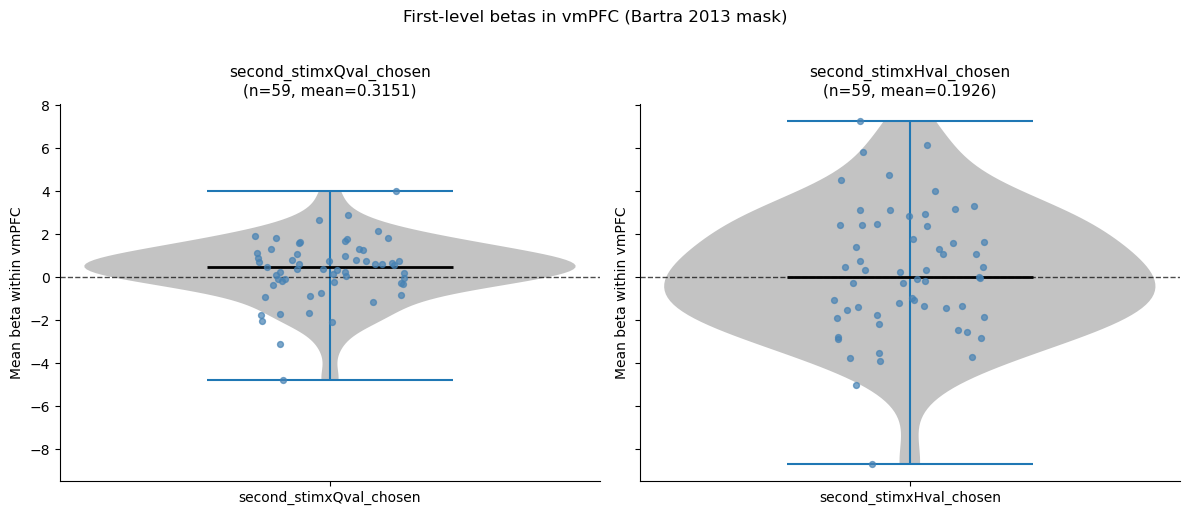

In [2]:
contrast_names = list(betas.keys())
fig, axes = plt.subplots(1, len(contrast_names), figsize=(6 * len(contrast_names), 5), sharey=True)

for ax, contrast_name in zip(axes, contrast_names):
    data  = betas[contrast_name]
    subs  = [s for s, _ in data]
    vals  = np.array([v for _, v in data])

    parts = ax.violinplot([vals], positions=[0], showmedians=True, showextrema=True)
    parts['bodies'][0].set_facecolor('#888888')
    parts['bodies'][0].set_alpha(0.5)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)

    jitter = np.random.RandomState(42).uniform(-0.08, 0.08, len(vals))
    ax.scatter(jitter, vals, s=18, alpha=0.7, color='steelblue', zorder=3)

    ax.axhline(0, color='black', lw=1, ls='--', alpha=0.7)
    ax.set_xticks([0])
    ax.set_xticklabels([contrast_name])
    ax.set_ylabel('Mean beta within vmPFC')
    ax.set_title(f'{contrast_name}\n(n={len(vals)}, mean={vals.mean():.4f})', fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('First-level betas in vmPFC (Bartra 2013 mask)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


In [3]:
print("Outlier subjects (|beta| > 2 SD from group mean):")
for contrast_name, data in betas.items():
    vals   = np.array([v for _, v in data])
    subs   = [s for s, _ in data]
    mean_b = vals.mean()
    std_b  = vals.std()
    outliers = [(s, v) for s, v in zip(subs, vals) if abs(v - mean_b) > 2 * std_b]
    if outliers:
        print(f"\n  {contrast_name}  (mean={mean_b:.4f}, sd={std_b:.4f})")
        for s, v in sorted(outliers, key=lambda x: abs(x[1] - mean_b), reverse=True):
            print(f"    {s}  beta={v:.4f}  ({(v - mean_b) / std_b:+.1f} SD)")
    else:
        print(f"\n  {contrast_name}: no outliers")


Outlier subjects (|beta| > 2 SD from group mean):

  second_stimxQval_chosen  (mean=0.3151, sd=1.4317)
    sub-33  beta=-4.7646  (-3.5 SD)
    sub-70  beta=3.9886  (+2.6 SD)
    sub-62  beta=-3.1233  (-2.4 SD)

  second_stimxHval_chosen  (mean=0.1926, sd=2.9091)
    sub-57  beta=-8.6867  (-3.1 SD)
    sub-19  beta=7.2588  (+2.4 SD)
    sub-37  beta=6.1497  (+2.0 SD)


## Interpretation

### second_stimxQval_chosen — weak positive effect, not outlier-driven

Mean beta = +0.32 (SD = 1.43, n = 59). The distribution is positively shifted,
consistent with the weak positive group T (~1.3) seen in the unthresholded T-map.
Two subjects pull strongly negative (sub-33 at −3.5 SD, sub-62 at −2.4 SD) but
the positive mean survives them, suggesting the majority of subjects lean positive
rather than the mean being purely outlier-driven. The effect is real but small —
underpowered rather than absent — which is consistent with the failed vmPFC SVC.

### second_stimxHval_chosen — noise, not a real effect

Mean beta = +0.19 (SD = 2.91). The SD is ~15× the mean, three outliers pull in
opposite directions, and the positive sign here contradicts the negative mean T seen
in the broader HO vmPFC mask from the T-map analysis. The H-val result in vmPFC is
entirely noise — no consistent directional signal across subjects.